**Homework 2: k-Means**

We begin as usual with some imports:

In [1]:
import numpy as np
from sklearn.datasets import load_digits
from matplotlib.pyplot import imshow

Matplotlib is building the font cache; this may take a moment.


The following code block loads the `digits` dataset. Each row of this dataset represents the pixel intensity (on a scale of 0 to 16) in an 8x8 image of a handwritten digit. There are 1797 images represented here. When you run this code block, you'll see the first two rows, corresponding to the pixel intensities of the first two images.

In [2]:
digits=load_digits().data
digits[:2,:]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
        15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
        12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
         0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
        10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.,  0.,  0.,  0., 11., 16.,
         9.,  0.,  0.,  0.,  0.,  3., 15., 16.,  6.,  0.,  0.,  0.,  7.,
        15., 16., 16.,  2.,  0.,  0.,  0.,  0.,  1., 16., 16.,  3.,  0.,
         0.,  0.,  0.,  1., 16., 16.,  6.,  0.,  0.,  0.,  0.,  1., 16.,
        16.,  6.,  0.,  0.,  0.,  0.,  0., 11., 16., 10.,  0.,  0.]])

To display an image represented by a particluar row, we can use the `imshow` command from matplotlib.pyplot. For example, the following code block will show you the image represented by the pixel values in row 100.

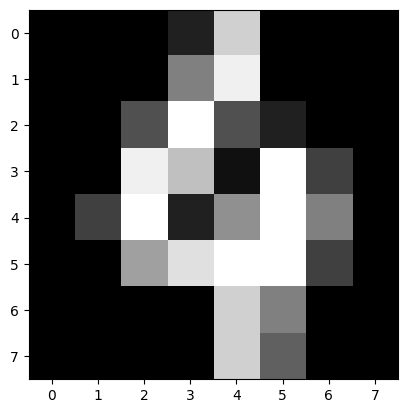

In [3]:
imshow(np.array(digits[100,:]).reshape((8,8)),cmap='gray')

The next block loads the `target` array that accompanies the digits dataset. Each entry is one of the digits 0-9, which tells us what the corresponding image is of in the digits dataset. For example, the image above is clearly the number "4". So we see that entry 100 in the target array is 4.

In [4]:
target=load_digits().target
target[100]

4

The goal of this assignment is to determine to what extent images of the same digit are clustered within the space of all possible 8x8 images. To determine this, you will implement the KMeans algorithm, as described in class.

## A two-dimensional view of the digits

Each image has 64 features, so we cannot plot the original data directly. As in Homework 1, PCA can project the data into two dimensions for visualization. The digit labels are used only to color the points; PCA itself does not use `target`.

In [5]:
# Import PCA and pyplot for the visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Fit PCA once to the 64-dimensional digit images, then transform every image into the same two-dimensional coordinate system.

In [6]:
# Fit the two-dimensional PCA projection
pca = PCA(n_components=2)
digits_2d = pca.fit_transform(digits)

print("original shape:", digits.shape)
print("projected shape:", digits_2d.shape)
print(
    "variance retained:",
    round(float(pca.explained_variance_ratio_.sum()), 3),
)

original shape: (1797, 64)
projected shape: (1797, 2)
variance retained: 0.285


The colors reveal where images of the same numeral tend to gather. Some colors form fairly distinct regions, while others overlap. Remember that PCA discards information: two points that appear close in this picture need not be close in the original 64-dimensional space.

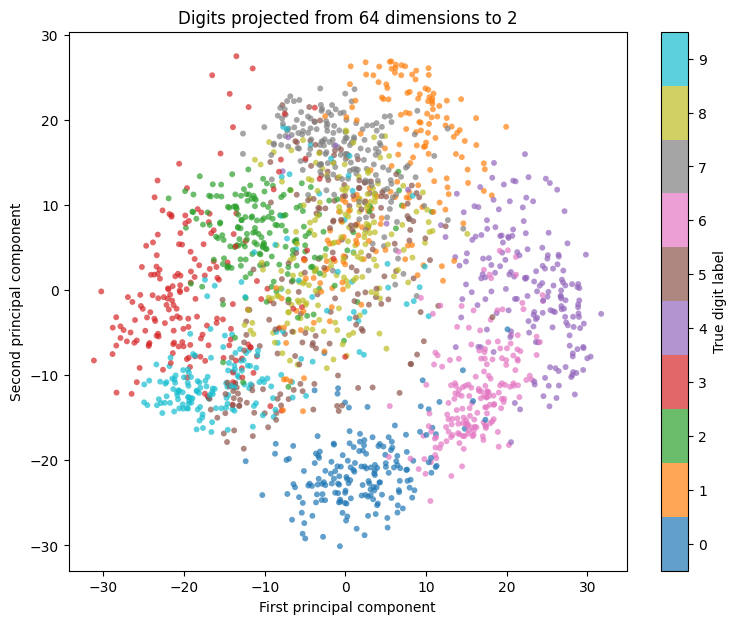

In [7]:
# Plot the PCA projection, colored by the true digit label
fig, ax = plt.subplots(figsize=(9, 7))
points = ax.scatter(
    digits_2d[:, 0],
    digits_2d[:, 1],
    c=target,
    cmap="tab10",
    vmin=-0.5,
    vmax=9.5,
    s=18,
    alpha=0.7,
    linewidths=0,
)
colorbar = fig.colorbar(points, ax=ax, ticks=range(10))
colorbar.set_label("True digit label")
ax.set(
    xlabel="First principal component",
    ylabel="Second principal component",
    title="Digits projected from 64 dimensions to 2",
)
plt.show()

Your first task is to write a function that takes a feature matrix like `digits`, and an  array like `target` of labels for each row, and returns an array whose rows are the centers of all the points in `data` with the same label.

For example, if there are 1797 rows of `data` (like in the `digits` dataset), and each row has 64 entries ("features"), then `data` will be an array of shape (1797,64). If there are 10 different kind of labels in the `labels` array, then the function you will write will output an array of shape (10,64). The first row contains the coordinates of the center of all points in `data` with label 0, the second the center of all points with label 1, etc. (It's OK to use a for-loop here to construct each row of this array.)

In [8]:
def centers_from_labels(data,labels):
    width=data.shape[1]
    height=len(np.bincount(labels))
    centers=np.zeros((height,width))
    for i in range(height):
        centers[i,:]=np.mean(data[labels==i],axis=0)
    return centers

Next, create a function called `sq_distances`. The columns of the array this returns should be the distances to the corresponding center. So, for example if `centers` has 10 rows, then there are 10 centers. Column 1 of `sq_distances(data,centers)` should be the squared distance from each point (row) of `data` to center 1. Column 2 should be the squared distances to center 2, etc. If `data` has shape (n,m) and centers has shape (k,m), then `sq_distances(data,centers)` should have shape (n,k).

In [9]:
def sq_distances(data,centers):
  k=len(centers)
  n=len(data)
  distances=np.zeros((n,k))
  for i in range(k):
    distances[:,i]=np.sum((data-centers[i,:])**2,axis=1)
  return distances

Now write a function that produces a 1-dimensional array, containing the number of the center that is closest to each point (row) in `data`.

In [10]:
def labels_from_centers(data,centers):
  distances=sq_distances(data,centers)
  return np.argmin(distances,axis=1)

If you have completed the previous problems correctly, the following code block should define the KMeans clustering algorithm. Make sure you understand it!

In [11]:
class KMeans():
    def __init__(self,k):
        self.k=k #Record the hyperparameter

    def fit(self,data):
        rng = np.random.default_rng(seed=1)#Define random number generator. Set seed only for gradescope!
        self.centers=rng.choice(data,size=self.k,replace=False,axis=0) #Choose 10 centers randomly
        labels=labels_from_centers(data,self.centers) #Decide which center each point is closest to
        diff=10
        while diff!=0: #Do this until labeling doesn't change
            old_labels=labels
            self.centers=centers_from_labels(data,labels) #Find center of each cluster
            labels=labels_from_centers(data,self.centers) #update labels based on closest center
            diff=np.sum((old_labels-labels)**2) #measure if labeling has changed
            print(diff) #Watch the algorithm converge!

    def predict(self,x):
        return labels_from_centers(x,self.centers) #Prediction is based on which center is closest

Run the next code block to find 10 clusters in the `digits` dataset, and assign each row to a cluster. You'll see the algorithm converging as it runs.

In [12]:
kmeans=KMeans(10)
kmeans.fit(digits)
clusters=kmeans.predict(digits)

3450
1843
2115
2193
1483
541
269
108
4
0


In [13]:
clusters[100]

7

In [14]:
clusters[1000]

6

Next, we want to examine the correspondence between the clusters generated by KMeans and the numerals represented by the images in `digits`. Create a function which takes `clusters`, `target` and `k`, and produces a Numpy array of shape (k,k). The (i,j) entry should represent the number of rows in `digits` that were in cluster i, and represent digit j.

In [15]:
def confusion_matrix(clusters,target,k):
  matrix=np.zeros((k,k))
  for i in range(k):
    for j in range(k):
      matrix[i,j]=np.sum((clusters==i) & (target==j))
  return matrix

In [16]:
confusion_matrix(clusters,target,10)

array([[  0.,   0.,   0.,   2.,   7.,   0.,   0.,  93.,   0.,   1.],
       [  0., 100.,   8.,   7.,   2.,   0.,   3.,   0., 103.,   1.],
       [  0.,   0.,   4.,   6.,   3.,   0.,   0.,  86.,   7.,  10.],
       [  0.,   0.,  12., 164.,   0.,  40.,   0.,   0.,  47., 145.],
       [  0.,   2.,   0.,   0.,   0.,   2., 177.,   0.,   2.,   0.],
       [176.,   0.,   1.,   0.,   0.,   0.,   1.,   0.,   0.,   0.],
       [  0.,  25., 150.,   1.,   0.,   0.,   0.,   0.,   4.,   0.],
       [  2.,   0.,   0.,   0., 166.,   2.,   0.,   0.,   0.,   0.],
       [  0.,   1.,   0.,   3.,   0., 138.,   0.,   0.,   5.,   4.],
       [  0.,  54.,   2.,   0.,   3.,   0.,   0.,   0.,   6.,  19.]])

Notice that in almost every row there is one number that is significantly larger than the rest. For example, the number 150 should be in row 6, column 2. That means that 150 of the points in cluster 6 are images of the numeral 2. Only 30 points in this cluster are images of other numerals.

We can now measure to what extent the digits are in distinct clusters. We simply take the largest number in each row, and divide it by the total number of images in `digits`. The result will be a number between 0 and 1 that tells you what percent of the images are in clusters that correlate to digits. Run the following code block to see it.

In [17]:
matrix=confusion_matrix(clusters,target,10)
np.sum(matrix.max(axis=1))/np.sum(matrix)

0.7273233166388425

You should end up with a number around 73%. One way to interpret this is that if you were to guess which numeral is represented by a given image according to its cluster, you'd be correct 73% of the time. While that may seem low (KNN, for example, might do better), keep in mind:
1. This is an unsupervised algorithm. Unlike KNN, we don't need the `target` data to implement the algorithm (only to check its accuracy).
2. 73% is MUCH higher than 10%, which is how often you'd be correct if you just randomly guessed.
3. Some of the clusters are more distinct. For example, if we just wanted to determine if a given image is a "0" or not, we just check if it represents a point in cluster 5. The accuracy of that will be much higher, since almost all "0"'s are in cluster 5 (176 out of 178), and very few points in cluster 5 are not "0" (only 2 out of 178).

## Where are the K-means centers in this picture?

K-means found its centers in the original 64-dimensional feature space. To place them on the same picture, transform those centers with the **already fitted** `pca` object. Do not fit a second PCA model to the ten centers: that would create a different coordinate system.

The large white stars are the projected cluster centers. The number inside each star is the cluster index, not a digit label. Each star is exactly the mean, in this two-dimensional view, of the points assigned to that cluster. It may not look like the center of the nearby visible cloud because cluster membership was determined in 64 dimensions, and nearby-looking points can belong to other clusters.

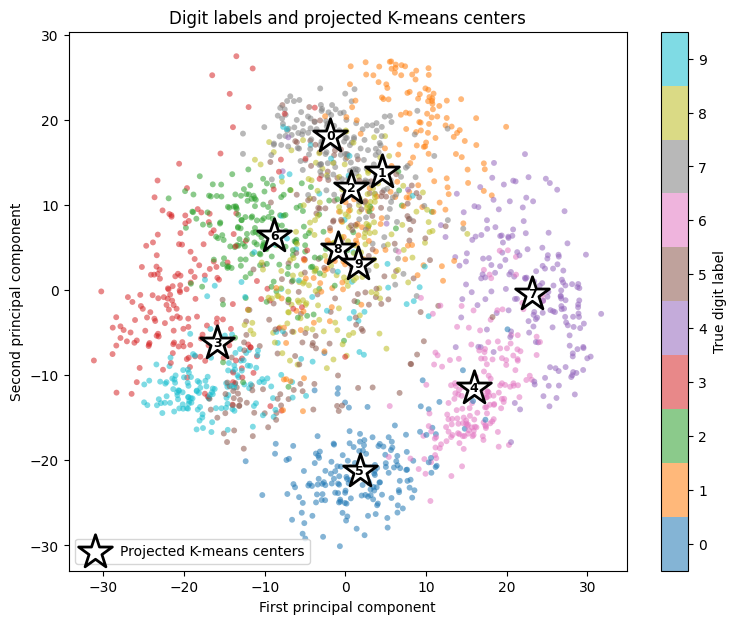

In [18]:
# Project the 64-dimensional K-means centers into the existing PCA view
cluster_centers_2d = pca.transform(kmeans.centers)

fig, ax = plt.subplots(figsize=(9, 7))
points = ax.scatter(
    digits_2d[:, 0],
    digits_2d[:, 1],
    c=target,
    cmap="tab10",
    vmin=-0.5,
    vmax=9.5,
    s=18,
    alpha=0.55,
    linewidths=0,
)
colorbar = fig.colorbar(points, ax=ax, ticks=range(10))
colorbar.set_label("True digit label")

ax.scatter(
    cluster_centers_2d[:, 0],
    cluster_centers_2d[:, 1],
    marker="*",
    s=650,
    facecolors="white",
    edgecolors="black",
    linewidths=2.0,
    label="Projected K-means centers",
    zorder=5,
)
for cluster_index, (x_coordinate, y_coordinate) in enumerate(cluster_centers_2d):
    ax.text(
        x_coordinate,
        y_coordinate,
        str(cluster_index),
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black",
        zorder=6,
    )

ax.set(
    xlabel="First principal component",
    ylabel="Second principal component",
    title="Digit labels and projected K-means centers",
)
ax.legend(loc="best")
plt.show()